In [44]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

All calculations here are based on the days with >= 70% CGM data coverage.

In [ ]:
def time_in_range_per_day(file_path, threshold=15):
    """
    Calculates the number of minutes per day where BG readings are in the 70–180 mg/dL range.

    Parameters
    ----------
    file_path : str
        Path to the CSV file containing 'timestamp' and 'BGvalue' columns.
    threshold : int, optional
        Maximum gap (in minutes) allowed between consecutive readings to cap time contribution.
        Default is 15 minutes.

    Returns
    -------
    pd.DataFrame
        A DataFrame with columns:
        - 'date': date of recording
        - 'in_range_minutes': total minutes in [70, 180] range that day
        - 'total_minutes': total CGM minutes that day (capped)
        - 'in_range_ratio': proportion of time in target range
    """
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")
        return [], [], []

    # Skip files with no data (only headers or empty content)
    if df.empty or len(df.columns) < 3:  # Ensure at least 'timestamp', 'BGvalue', and 'date' columns exist
        print(f"Skipping empty or invalid file: {file_path}")
        return [], [], []
    
    df = pd.read_csv(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', format='mixed')
    df = df.dropna(subset=['timestamp', 'BGvalue'])
    df['date'] = df['timestamp'].dt.date
    df = df.sort_values('timestamp')

    df['BGvalue'] = pd.to_numeric(df['BGvalue'], errors='coerce')
    df = df.dropna(subset=['BGvalue'])

    results = []

    for date, group in df.groupby('date'):
        group = group.sort_values('timestamp').reset_index(drop=True)

        # Compute time gaps (minutes) between consecutive readings
        time_diffs = group['timestamp'].diff().dt.total_seconds().div(60).iloc[1:]  # skip first NaN
        capped_diffs = np.minimum(time_diffs, threshold)

        # Align BG values with time gaps (use second reading in each pair)
        bg_values = group['BGvalue'].iloc[1:].values
        in_range_mask = (bg_values >= 70) & (bg_values <= 180)

        in_range_minutes = capped_diffs[in_range_mask].sum()
        total_minutes = capped_diffs.sum()
        in_range_ratio = 100*in_range_minutes / total_minutes if total_minutes > 0 else 0.0
        daily_mean_bg = group['BGvalue'].mean()
        daily_gly_var = group['BGvalue'].std() *100 / daily_mean_bg

        results.append({
            'date': date,
            'in_range_minutes': round(in_range_minutes, 1),
            'total_minutes': round(total_minutes, 1),
            'in_range_ratio': round(in_range_ratio, 2),
            'daily_mean_bg': round(daily_mean_bg, 1),
            'daily_gly_var': round(daily_gly_var, 2)
        })
    result_df = pd.DataFrame(results)

    return result_df['in_range_ratio'].to_list(), result_df['daily_mean_bg'].to_list(), result_df['daily_gly_var'].to_list()


# OhioT1DM

In [ ]:
# Folder path
# 2018
folder_path_2018_test = '../high_processed_OhioT1DM/2018/test'
folder_path_2018_train = '../high_processed_OhioT1DM/2018/train'
# List all files in the folder
file_names_2018_test = [f for f in os.listdir(folder_path_2018_test) if os.path.isfile(os.path.join(folder_path_2018_test, f))]
file_names_2018_train = [f for f in os.listdir(folder_path_2018_train) if os.path.isfile(os.path.join(folder_path_2018_train, f))]


# 2020
folder_path_2020_test = '../high_processed_OhioT1DM/2020/test'
folder_path_2020_train = '../high_processed_OhioT1DM/2020/train'
file_names_2020_test = [f for f in os.listdir(folder_path_2020_test) if os.path.isfile(os.path.join(folder_path_2020_test, f))]
file_names_2020_train = [f for f in os.listdir(folder_path_2020_train) if os.path.isfile(os.path.join(folder_path_2020_train, f))]

total_tir_ratio_ohio = []
total_mean_bg_ohio = []
total_gv_ohio = []

# Loop over DataFrames and accumulate counts
# Process files in the train folder
for input_file in file_names_2018_train:
    # Parse the CSV file
    if input_file != ".DS_Store":
        full_file_path = os.path.join(folder_path_2018_train, input_file)
        result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
        total_tir_ratio_ohio += result_list
        total_mean_bg_ohio += result_mean_bg
        total_gv_ohio += result_gv

for input_file in file_names_2018_test:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2018_test, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_ohio += result_list
    total_mean_bg_ohio += result_mean_bg
    total_gv_ohio += result_gv

for input_file in file_names_2020_train:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2020_train, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_ohio += result_list
    total_mean_bg_ohio += result_mean_bg
    total_gv_ohio += result_gv

for input_file in file_names_2020_test:
    # Parse the CSV file
    full_file_path = os.path.join(folder_path_2020_test, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_ohio += result_list
    total_mean_bg_ohio += result_mean_bg
    total_gv_ohio += result_gv

In [48]:
len(total_tir_ratio_ohio)

569

# T1DEXI

In [ ]:
folder_path_t1dexi = '../high_processed_T1DEXI/'
file_names_t1dexi= [f for f in os.listdir(folder_path_t1dexi) if os.path.isfile(os.path.join(folder_path_t1dexi, f))]

total_tir_ratio_t1dexi = []
total_mean_bg_t1dexi = []
total_gv_t1dexi = []

for input_file in file_names_t1dexi:
    full_file_path = os.path.join(folder_path_t1dexi, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_t1dexi += result_list
    total_mean_bg_t1dexi += result_mean_bg
    total_gv_t1dexi += result_gv

Skipping empty or invalid file: ./high_processed_T1DEXI/filtered_329.csv
Skipping empty or invalid file: ./high_processed_T1DEXI/filtered_1606.csv
Skipping empty or invalid file: ./high_processed_T1DEXI/filtered_1118.csv
Skipping empty or invalid file: ./high_processed_T1DEXI/filtered_1093.csv
Skipping empty or invalid file: ./high_processed_T1DEXI/filtered_323.csv


# BIL

In [ ]:
folder_path_BIL = '../high_processed_BIL/'
file_names_BIL = [f for f in os.listdir(folder_path_BIL) if os.path.isfile(os.path.join(folder_path_BIL, f))]

total_tir_ratio_BIL = []
total_mean_bg_BIL = []
total_gv_BIL = []

for input_file in file_names_BIL:
    full_file_path = os.path.join(folder_path_BIL, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_BIL += result_list
    total_mean_bg_BIL += result_mean_bg
    total_gv_BIL += result_gv

# DiaTrend

In [ ]:
folder_path_Diatrend = '../high_processed_Diatrend/'
file_names_Diatrend = [f for f in os.listdir(folder_path_Diatrend) if os.path.isfile(os.path.join(folder_path_Diatrend, f))]

total_tir_ratio_Diatrend = []
total_mean_bg_Diatrend = []
total_gv_Diatrend = []

for input_file in file_names_Diatrend:
    full_file_path = os.path.join(folder_path_Diatrend, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_Diatrend += result_list
    total_mean_bg_Diatrend += result_mean_bg
    total_gv_Diatrend += result_gv

# ShanghaiT1DM

In [ ]:
folder_path_shanghait1 = '../high_processed_shanghait1dm/'
file_names_shanghait1 = [f for f in os.listdir(folder_path_shanghait1) if os.path.isfile(os.path.join(folder_path_shanghait1, f))]

total_tir_ratio_shanghait1 = []
total_mean_bg_shanghait1 = []
total_gv_shanghait1 = []

for input_file in file_names_shanghait1:
    full_file_path = os.path.join(folder_path_shanghait1, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_shanghait1 += result_list
    total_mean_bg_shanghait1 += result_mean_bg
    total_gv_shanghait1 += result_gv

# ShanghaiT2DM

In [ ]:
folder_path_shanghait2 = '../high_processed_shanghait2dm/'
file_names_shanghait2 = [f for f in os.listdir(folder_path_shanghait2) if os.path.isfile(os.path.join(folder_path_shanghait2, f))]

total_tir_ratio_shanghait2 = []
total_mean_bg_shanghait2 = []
total_gv_shanghait2 = []

for input_file in file_names_shanghait2:
    full_file_path = os.path.join(folder_path_shanghait2, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_shanghait2 += result_list
    total_mean_bg_shanghait2 += result_mean_bg
    total_gv_shanghait2 += result_gv

# T1DiabetesGranada

In [ ]:
folder_path_t1diabetesgranada = '../high_processed_T1DiabetesGranada/'
file_names_t1diabetesgranada = [f for f in os.listdir(folder_path_t1diabetesgranada) if os.path.isfile(os.path.join(folder_path_t1diabetesgranada, f))]

total_tir_ratio_t1diabetesgranada = []
total_mean_bg_t1diabetesgranada = []
total_gv_t1diabetesgranada = []

for input_file in file_names_t1diabetesgranada:
    full_file_path = os.path.join(folder_path_t1diabetesgranada, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_t1diabetesgranada += result_list
    total_mean_bg_t1diabetesgranada += result_mean_bg
    total_gv_t1diabetesgranada += result_gv

Skipping empty or invalid file: ./high_processed_T1DiabetesGranada/filtered_LIB193713.csv


# AI-READI

In [ ]:
folder_path_aireadi = '../high_processed_aireadi/'
file_names_aireadi = [f for f in os.listdir(folder_path_aireadi) if os.path.isfile(os.path.join(folder_path_aireadi, f))]

total_tir_ratio_aireadi = []
total_mean_bg_aireadi = []
total_gv_aireadi = []

for input_file in file_names_aireadi:
    full_file_path = os.path.join(folder_path_aireadi, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_aireadi += result_list
    total_mean_bg_aireadi += result_mean_bg
    total_gv_aireadi += result_gv

Skipping empty or invalid file: ./high_processed_aireadi/filtered_4034_DEX.csv
Skipping empty or invalid file: ./high_processed_aireadi/filtered_1111_DEX.csv
Skipping empty or invalid file: ./high_processed_aireadi/filtered_7052_DEX.csv
Skipping empty or invalid file: ./high_processed_aireadi/filtered_7009_DEX.csv
Skipping empty or invalid file: ./high_processed_aireadi/filtered_7008_DEX.csv


# UCHTT1DM

In [ ]:
folder_path_uchtt1dm = '../high_processed_UCHTT1DM/'
file_names_uchtt1dm = [f for f in os.listdir(folder_path_uchtt1dm) if os.path.isfile(os.path.join(folder_path_uchtt1dm, f))]

total_tir_ratio_uchtt1dm = []
total_mean_bg_uchtt1dm = []
total_gv_uchtt1dm = []

for input_file in file_names_uchtt1dm:
    full_file_path = os.path.join(folder_path_uchtt1dm, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_uchtt1dm += result_list
    total_mean_bg_uchtt1dm += result_mean_bg
    total_gv_uchtt1dm += result_gv

# CGMacros

In [ ]:
folder_path_CGMacros_dexcom = '../high_processed_cgmacros/Dexcom GL'
file_names_CGMacros_dexcom = [f for f in os.listdir(folder_path_CGMacros_dexcom) if os.path.isfile(os.path.join(folder_path_CGMacros_dexcom, f))]
# folder_path_CGMacros_libre = './high_processed_cgmacros/Libre GL'
# file_names_CGMacros_libre = [f for f in os.listdir(folder_path_CGMacros_libre) if os.path.isfile(os.path.join(folder_path_CGMacros_libre, f))]

total_tir_ratio_cgmacros = []
total_mean_bg_cgmacros = []
total_gv_cgmacros = []

for input_file in file_names_CGMacros_dexcom:
    full_file_path = os.path.join(folder_path_CGMacros_dexcom, input_file)
    result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
    total_tir_ratio_cgmacros += result_list
    total_mean_bg_cgmacros += result_mean_bg
    total_gv_cgmacros += result_gv

# for input_file in file_names_CGMacros_libre:
#     full_file_path = os.path.join(folder_path_CGMacros_libre, input_file)
#     result_list, result_mean_bg, result_gv = time_in_range_per_day(full_file_path)
#     total_tir_ratio_cgmacros += result_list
#     total_mean_bg_cgmacros += result_mean_bg
#     total_gv_cgmacros += result_gv

# Summary

In [63]:
# Dictionary to store dataset names and their corresponding TIR ratio lists
tir_ratios = {
    "OhioT1DM": total_tir_ratio_ohio,
    "T1DEXI": total_tir_ratio_t1dexi,
    "BIL": total_tir_ratio_BIL,
    "Diatrend": total_tir_ratio_Diatrend,
    "ShanghaiT1DM": total_tir_ratio_shanghait1,
    "ShanghaiT2DM": total_tir_ratio_shanghait2,
    "T1DiabetesGranada": total_tir_ratio_t1diabetesgranada,
    "AI-READI": total_tir_ratio_aireadi,
    "UCHTT1DM": total_tir_ratio_uchtt1dm,
    "CGMacros": total_tir_ratio_cgmacros
}

# Loop through the dictionary and calculate statistics for each dataset
for dataset, ratios in tir_ratios.items():
    print(f"====={dataset}=====")
    print("Mean TIR Ratio: ", np.average(ratios))
    print("STD TIR Ratio: ", np.std(ratios))
    print("Range TIR Ratio: ", np.max(ratios), "-", np.min(ratios))

=====OhioT1DM=====
Mean TIR Ratio:  63.19769771528999
STD TIR Ratio:  20.69665116794683
Range TIR Ratio:  100.0 - 0.0
=====T1DEXI=====
Mean TIR Ratio:  74.68537432545412
STD TIR Ratio:  19.97833774286439
Range TIR Ratio:  100.0 - 0.0
=====BIL=====
Mean TIR Ratio:  97.6608695652174
STD TIR Ratio:  3.803249540845734
Range TIR Ratio:  100.0 - 79.09
=====Diatrend=====
Mean TIR Ratio:  50.72437401970642
STD TIR Ratio:  22.418665079360625
Range TIR Ratio:  100.0 - 0.0
=====ShanghaiT1DM=====
Mean TIR Ratio:  53.37814569536424
STD TIR Ratio:  22.60604005332823
Range TIR Ratio:  100.0 - 0.0
=====ShanghaiT2DM=====
Mean TIR Ratio:  79.21065018315018
STD TIR Ratio:  21.89223411822448
Range TIR Ratio:  100.0 - 0.0
=====T1DiabetesGranada=====
Mean TIR Ratio:  59.884747413347135
STD TIR Ratio:  23.308244478767985
Range TIR Ratio:  100.0 - 0.0
=====AI-READI=====
Mean TIR Ratio:  85.72003789818703
STD TIR Ratio:  23.547622594785068
Range TIR Ratio:  100.0 - 0.0
=====UCHTT1DM=====
Mean TIR Ratio:  86.46

In [64]:
# Dictionary to store dataset names and their corresponding TIR ratio lists
mean_BGs = {
    "OhioT1DM": total_mean_bg_ohio,
    "T1DEXI": total_mean_bg_t1dexi,
    "BIL": total_mean_bg_BIL,
    "Diatrend": total_mean_bg_Diatrend,
    "ShanghaiT1DM": total_mean_bg_shanghait1,
    "ShanghaiT2DM": total_mean_bg_shanghait2,
    "T1DiabetesGranada": total_mean_bg_t1diabetesgranada,
    "AI-READI": total_mean_bg_aireadi,
    "UCHTT1DM": total_mean_bg_uchtt1dm,
    "CGMacros": total_mean_bg_cgmacros
}

# Loop through the dictionary and calculate statistics for each dataset
for dataset, ratios in mean_BGs.items():
    print(f"====={dataset}=====")
    print("Mean avg BG: ", np.average(ratios))
    print("STD avg BG: ", np.std(ratios))
    print("Range avg BG: ", np.max(ratios), "-", np.min(ratios))

=====OhioT1DM=====
Mean avg BG:  160.07943760984185
STD avg BG:  31.09023686796569
Range avg BG:  277.6 - 99.4
=====T1DEXI=====
Mean avg BG:  146.10826176179978
STD avg BG:  32.055863409955165
Range avg BG:  365.9 - 66.4
=====BIL=====
Mean avg BG:  114.05304347826088
STD avg BG:  11.554944898475513
Range avg BG:  135.5 - 86.2
=====Diatrend=====
Mean avg BG:  186.53525035190026
STD avg BG:  41.16897983416429
Range avg BG:  397.2 - 70.3
=====ShanghaiT1DM=====
Mean avg BG:  165.0377483443709
STD avg BG:  42.893165823942695
Range avg BG:  257.1 - 57.2
=====ShanghaiT2DM=====
Mean avg BG:  139.8897435897436
STD avg BG:  33.88451547995844
Range avg BG:  285.9 - 40.6
=====T1DiabetesGranada=====
Mean avg BG:  164.10814450767376
STD avg BG:  42.055535828007315
Range avg BG:  493.7 - 48.9
=====AI-READI=====
Mean avg BG:  139.00857318447197
STD avg BG:  39.69262051007108
Range avg BG:  395.3 - 47.5
=====UCHTT1DM=====
Mean avg BG:  110.55773195876289
STD avg BG:  30.814388910509873
Range avg BG:  2

In [65]:
# Dictionary to store dataset names and their corresponding TIR ratio lists
GVs = {
    "OhioT1DM": total_gv_ohio,
    "T1DEXI": total_gv_t1dexi,
    "BIL": total_gv_BIL,
    "Diatrend": total_gv_Diatrend,
    "ShanghaiT1DM": total_gv_shanghait1,
    "ShanghaiT2DM": total_gv_shanghait2,
    "T1DiabetesGranada": total_gv_t1diabetesgranada,
    "AI-READI": total_gv_aireadi,
    "UCHTT1DM": total_gv_uchtt1dm,
    "CGMacros": total_gv_cgmacros
}

# Loop through the dictionary and calculate statistics for each dataset
for dataset, ratios in GVs.items():
    print(f"====={dataset}=====")
    print("Mean GV: ", np.average(ratios))
    print("STD GV: ", np.std(ratios))
    print("Range GV: ", np.max(ratios), "-", np.min(ratios))

=====OhioT1DM=====
Mean GV:  31.453936731107206
STD GV:  8.474926710283631
Range GV:  57.18 - 11.66
=====T1DEXI=====
Mean GV:  29.178368929087178
STD GV:  8.43366489068814
Range GV:  79.97 - 6.58
=====BIL=====
Mean GV:  16.54417391304348
STD GV:  5.157596673647051
Range GV:  37.75 - 5.26
=====Diatrend=====
Mean GV:  32.02842911723306
STD GV:  8.726296172607823
Range GV:  91.34 - 3.22
=====ShanghaiT1DM=====
Mean GV:  33.279337748344375
STD GV:  10.373768093710453
Range GV:  78.28 - 12.9
=====ShanghaiT2DM=====
Mean GV:  24.723589743589745
STD GV:  7.777923742005418
Range GV:  55.76 - 6.4
=====T1DiabetesGranada=====
Mean GV:  32.677492412484916
STD GV:  10.006815620984396
Range GV:  101.11 - 3.25
=====AI-READI=====
Mean GV:  17.69196865717505
STD GV:  6.308462770446514
Range GV:  60.08 - 1.29
=====UCHTT1DM=====
Mean GV:  21.146494845360824
STD GV:  11.623068338902518
Range GV:  62.6 - 6.58
=====CGMacros=====
Mean GV:  18.691724999999998
STD GV:  6.434157930481269
Range GV:  42.25 - 7.08


# Figure

/var/folders/j5/tbqtlr256g5b8t969rk8d5kr0000gn/T/ipykernel_57890/1823647039.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='group', y='value', data=df, inner='box', palette=custom_palette)


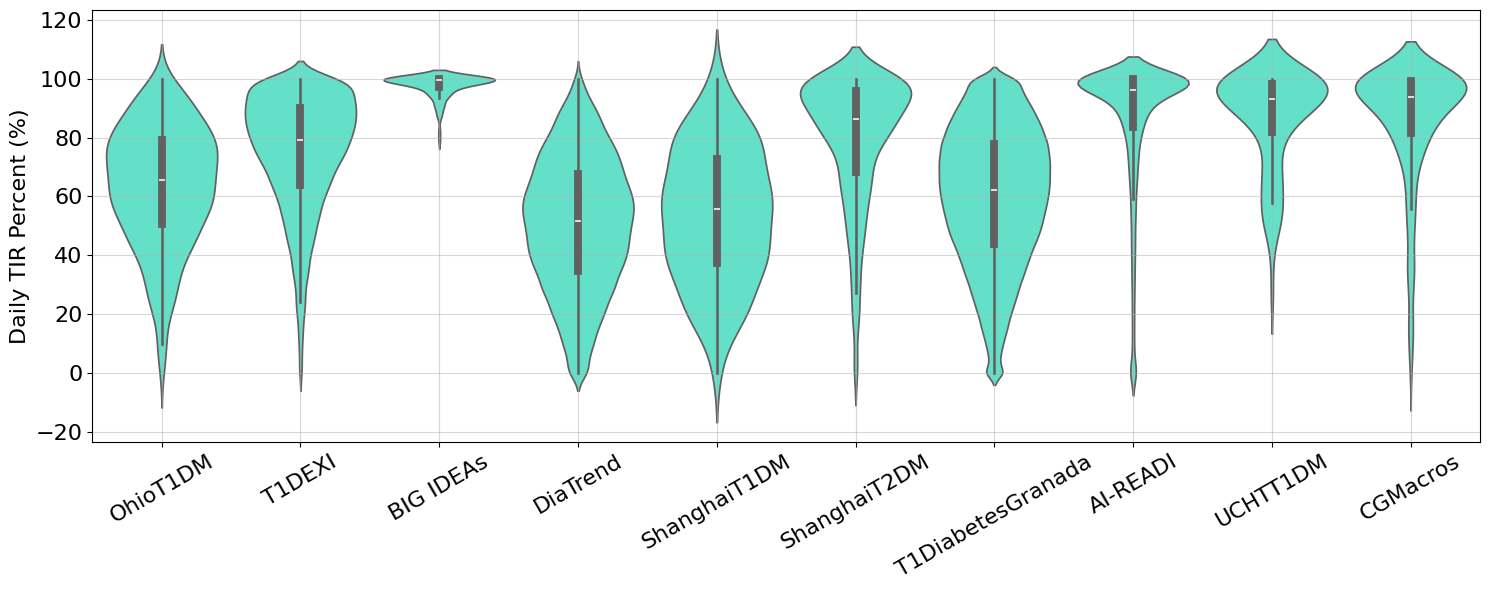

In [35]:
import seaborn as sns

# Put all data into a long-form DataFrame
df = pd.DataFrame({
    'value': total_tir_ratio_ohio + total_tir_ratio_t1dexi + total_tir_ratio_BIL + total_tir_ratio_Diatrend + total_tir_ratio_shanghait1 + total_tir_ratio_shanghait2 + total_tir_ratio_t1diabetesgranada + total_tir_ratio_aireadi + total_tir_ratio_uchtt1dm + total_tir_ratio_cgmacros,
    'group': ['OhioT1DM'] * len(total_tir_ratio_ohio) + ['T1DEXI'] * len(total_tir_ratio_t1dexi) + ['BIG IDEAs'] * len(total_tir_ratio_BIL) + ['DiaTrend'] * len(total_tir_ratio_Diatrend) + ['ShanghaiT1DM'] * len(total_tir_ratio_shanghait1) + ['ShanghaiT2DM'] * len(total_tir_ratio_shanghait2) + ['T1DiabetesGranada'] * len(total_tir_ratio_t1diabetesgranada) + ['AI-READI'] * len(total_tir_ratio_aireadi) + ['UCHTT1DM'] * len(total_tir_ratio_uchtt1dm) + ['CGMacros'] * len(total_tir_ratio_cgmacros)
})

# Create a custom palette where all groups share the same color
unique_groups = df['group'].unique()
custom_palette = {group: '#4FF5D6' for group in unique_groups}

plt.figure(figsize=(15, 6))
sns.violinplot(x='group', y='value', data=df, inner='box', palette=custom_palette)


# Labels and title
plt.xlabel('', fontsize=14)
plt.ylabel('Daily TIR Percent (%)', fontsize=16)
# plt.title('Violin Plot of Multiple Groups', fontsize=16)

# Customize x-ticks
plt.xticks(rotation=30, fontsize=16)
plt.yticks(fontsize=16)

# Add grid and layout adjustments
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

/var/folders/j5/tbqtlr256g5b8t969rk8d5kr0000gn/T/ipykernel_57890/2167868562.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='group', y='value', data=df, inner='box', palette=custom_palette)


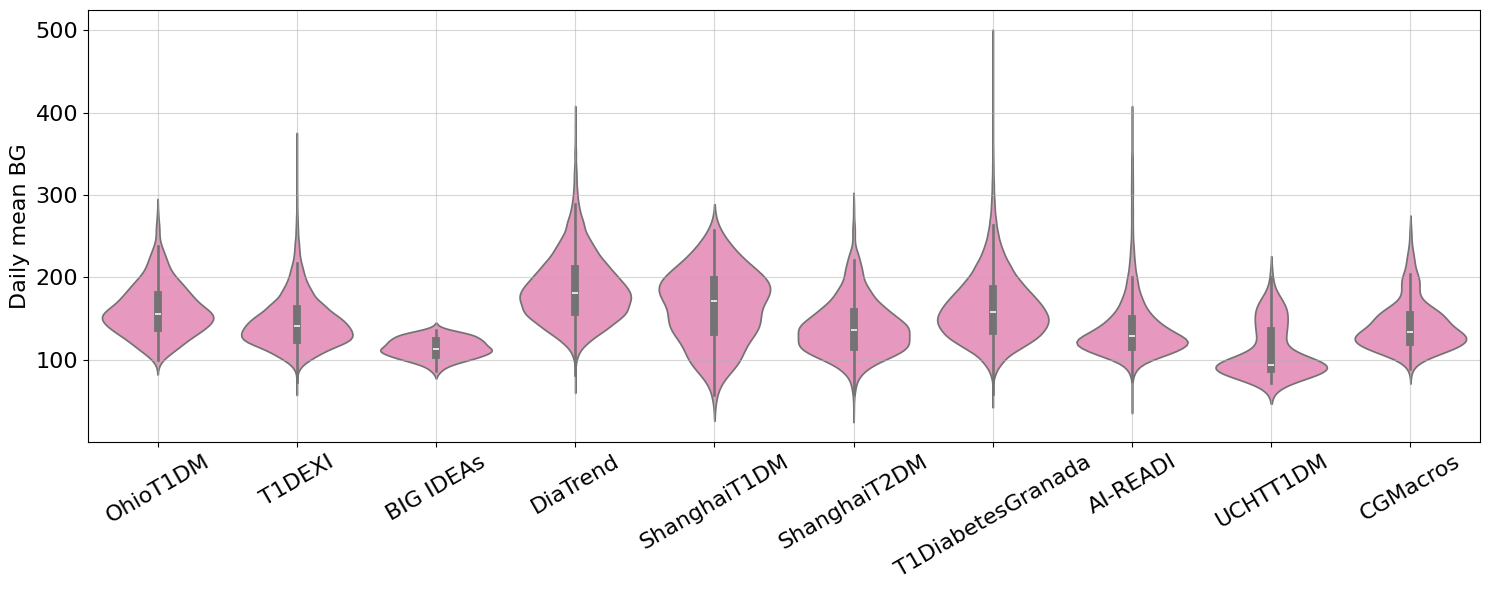

In [42]:
import seaborn as sns

# Put all data into a long-form DataFrame
df = pd.DataFrame({
    'value': total_mean_bg_ohio + total_mean_bg_t1dexi + total_mean_bg_BIL + total_mean_bg_Diatrend + total_mean_bg_shanghait1 + total_mean_bg_shanghait2 + total_mean_bg_t1diabetesgranada + total_mean_bg_aireadi + total_mean_bg_uchtt1dm + total_mean_bg_cgmacros,
    'group': ['OhioT1DM'] * len(total_mean_bg_ohio) + ['T1DEXI'] * len(total_mean_bg_t1dexi) + ['BIG IDEAs'] * len(total_mean_bg_BIL) + ['DiaTrend'] * len(total_mean_bg_Diatrend) + ['ShanghaiT1DM'] * len(total_mean_bg_shanghait1) + ['ShanghaiT2DM'] * len(total_mean_bg_shanghait2) + ['T1DiabetesGranada'] * len(total_mean_bg_t1diabetesgranada) + ['AI-READI'] * len(total_mean_bg_aireadi) + ['UCHTT1DM'] * len(total_mean_bg_uchtt1dm) + ['CGMacros'] * len(total_mean_bg_cgmacros)
})

# Create a custom palette where all groups share the same color
unique_groups = df['group'].unique()
custom_palette = {group: '#F48BBF' for group in unique_groups}

plt.figure(figsize=(15, 6))
sns.violinplot(x='group', y='value', data=df, inner='box', palette=custom_palette)

# Labels and title
plt.xlabel('', fontsize=14)
plt.ylabel('Daily mean BG', fontsize=16)
# plt.title('Violin Plot of Multiple Groups', fontsize=16)

# Customize x-ticks
plt.xticks(rotation=30, fontsize=16)
plt.yticks(fontsize=16)

# Add grid and layout adjustments
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

/var/folders/j5/tbqtlr256g5b8t969rk8d5kr0000gn/T/ipykernel_57890/2069850172.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='group', y='value', data=df, inner='box', palette=custom_palette)


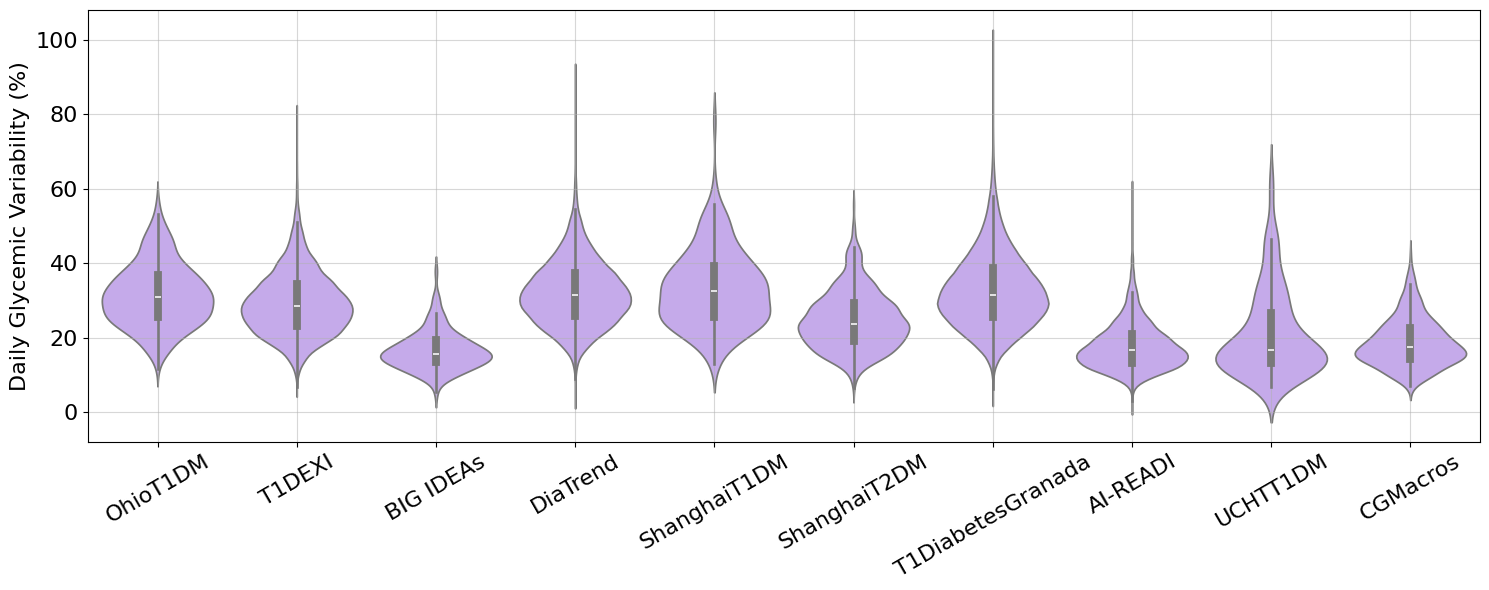

In [43]:
import seaborn as sns

# Put all data into a long-form DataFrame
df = pd.DataFrame({
    'value': total_gv_ohio + total_gv_t1dexi + total_gv_BIL + total_gv_Diatrend + total_gv_shanghait1 + total_gv_shanghait2 + total_gv_t1diabetesgranada + total_gv_aireadi + total_gv_uchtt1dm + total_gv_cgmacros,
    'group': ['OhioT1DM'] * len(total_gv_ohio) + ['T1DEXI'] * len(total_gv_t1dexi) + ['BIG IDEAs'] * len(total_gv_BIL) + ['DiaTrend'] * len(total_gv_Diatrend) + ['ShanghaiT1DM'] * len(total_gv_shanghait1) + ['ShanghaiT2DM'] * len(total_gv_shanghait2) + ['T1DiabetesGranada'] * len(total_gv_t1diabetesgranada) + ['AI-READI'] * len(total_gv_aireadi) + ['UCHTT1DM'] * len(total_gv_uchtt1dm) + ['CGMacros'] * len(total_gv_cgmacros)
})

# Create a custom palette where all groups share the same color
unique_groups = df['group'].unique()
custom_palette = {group: '#C39FF5' for group in unique_groups}

plt.figure(figsize=(15, 6))
sns.violinplot(x='group', y='value', data=df, inner='box', palette=custom_palette)

# Labels and title
plt.xlabel('', fontsize=12)
plt.ylabel('Daily Glycemic Variability (%)', fontsize=16)
# plt.title('Violin Plot of Multiple Groups', fontsize=16)

# Customize x-ticks
plt.xticks(rotation=30, fontsize=16)
plt.yticks(fontsize=16)

# Add grid and layout adjustments
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()